# Template Pengerjaan Tugas Supervised Learning

## 1. Import Dataset dari Kaggle
- Akses situs Kaggle dan cari dataset yang relevan untuk tugas Supervised Learning.
- Unduh dataset menggunakan Kaggle API (jika tersedia) atau secara manual dengan mengklik tombol download pada halaman dataset.
- Simpan dataset ke dalam folder proyek dan pastikan format file sesuai (misalnya CSV atau ZIP yang perlu diekstrak).
- Load dataset ke dalam environment kerja menggunakan library yang sesuai, dan periksa struktur data awal seperti jumlah baris, kolom, dan tipe data.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

# Download dataset dari Kaggle
path = kagglehub.dataset_download("lara311/diabetes-dataset-using-many-medical-metrics")
print("Path to dataset files:", path)

# Cari file CSV dalam folder yang didownload
for file in os.listdir(path):
    print("File ditemukan:", file)

Using Colab cache for faster access to the 'diabetes-dataset-using-many-medical-metrics' dataset.
Path to dataset files: /kaggle/input/diabetes-dataset-using-many-medical-metrics
File ditemukan: diabetes (1).csv


In [2]:
# Load dataset ke dalam DataFrame
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("=== Informasi Awal Dataset ===")
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"\nNama kolom     : {list(df.columns)}")
print("\nTipe data setiap kolom:")
print(df.dtypes)
print("\nPreview 5 baris pertama:")
df.head()

=== Informasi Awal Dataset ===
Jumlah baris   : 768
Jumlah kolom   : 9

Nama kolom     : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Tipe data setiap kolom:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Preview 5 baris pertama:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. EDA (Exploratory Data Analysis)
- Lakukan analisis deskriptif untuk memahami distribusi data, termasuk statistik dasar seperti mean, median, mode, dan standar deviasi untuk setiap fitur.
- Visualisasikan data menggunakan plot seperti histogram, boxplot, scatter plot, atau heatmap korelasi untuk mengidentifikasi pola, outlier, dan hubungan antar variabel.
- Periksa missing values, duplikasi data, dan imbalance pada target variable jika ada.
- Identifikasi fitur-fitur penting yang mungkin mempengaruhi model berdasarkan analisis ini.

In [3]:
# 2.1 Statistik Deskriptif
print("=== Statistik Deskriptif ===")
print(df.describe().T.round(2))

=== Statistik Deskriptif ===
                          count    mean     std    min    25%     50%     75%  \
Pregnancies               768.0    3.85    3.37   0.00   1.00    3.00    6.00   
Glucose                   768.0  120.89   31.97   0.00  99.00  117.00  140.25   
BloodPressure             768.0   69.11   19.36   0.00  62.00   72.00   80.00   
SkinThickness             768.0   20.54   15.95   0.00   0.00   23.00   32.00   
Insulin                   768.0   79.80  115.24   0.00   0.00   30.50  127.25   
BMI                       768.0   31.99    7.88   0.00  27.30   32.00   36.60   
DiabetesPedigreeFunction  768.0    0.47    0.33   0.08   0.24    0.37    0.63   
Age                       768.0   33.24   11.76  21.00  24.00   29.00   41.00   
Outcome                   768.0    0.35    0.48   0.00   0.00    0.00    1.00   

                             max  
Pregnancies                17.00  
Glucose                   199.00  
BloodPressure             122.00  
SkinThickness       

In [4]:
# 2.2 Cek Missing Values, Duplikasi, dan Distribusi Target
print("=== Missing Values ===")
print(df.isnull().sum())

print(f"\n=== Duplikasi Data ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

print(f"\n=== Distribusi Target (Outcome) ===")
print(df['Outcome'].value_counts())
print(f"\nPersentase kelas:")
print(df['Outcome'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Duplikasi Data ===
Jumlah baris duplikat: 0

=== Distribusi Target (Outcome) ===
Outcome
0    500
1    268
Name: count, dtype: int64

Persentase kelas:
Outcome
0    65.1%
1    34.9%
Name: proportion, dtype: object


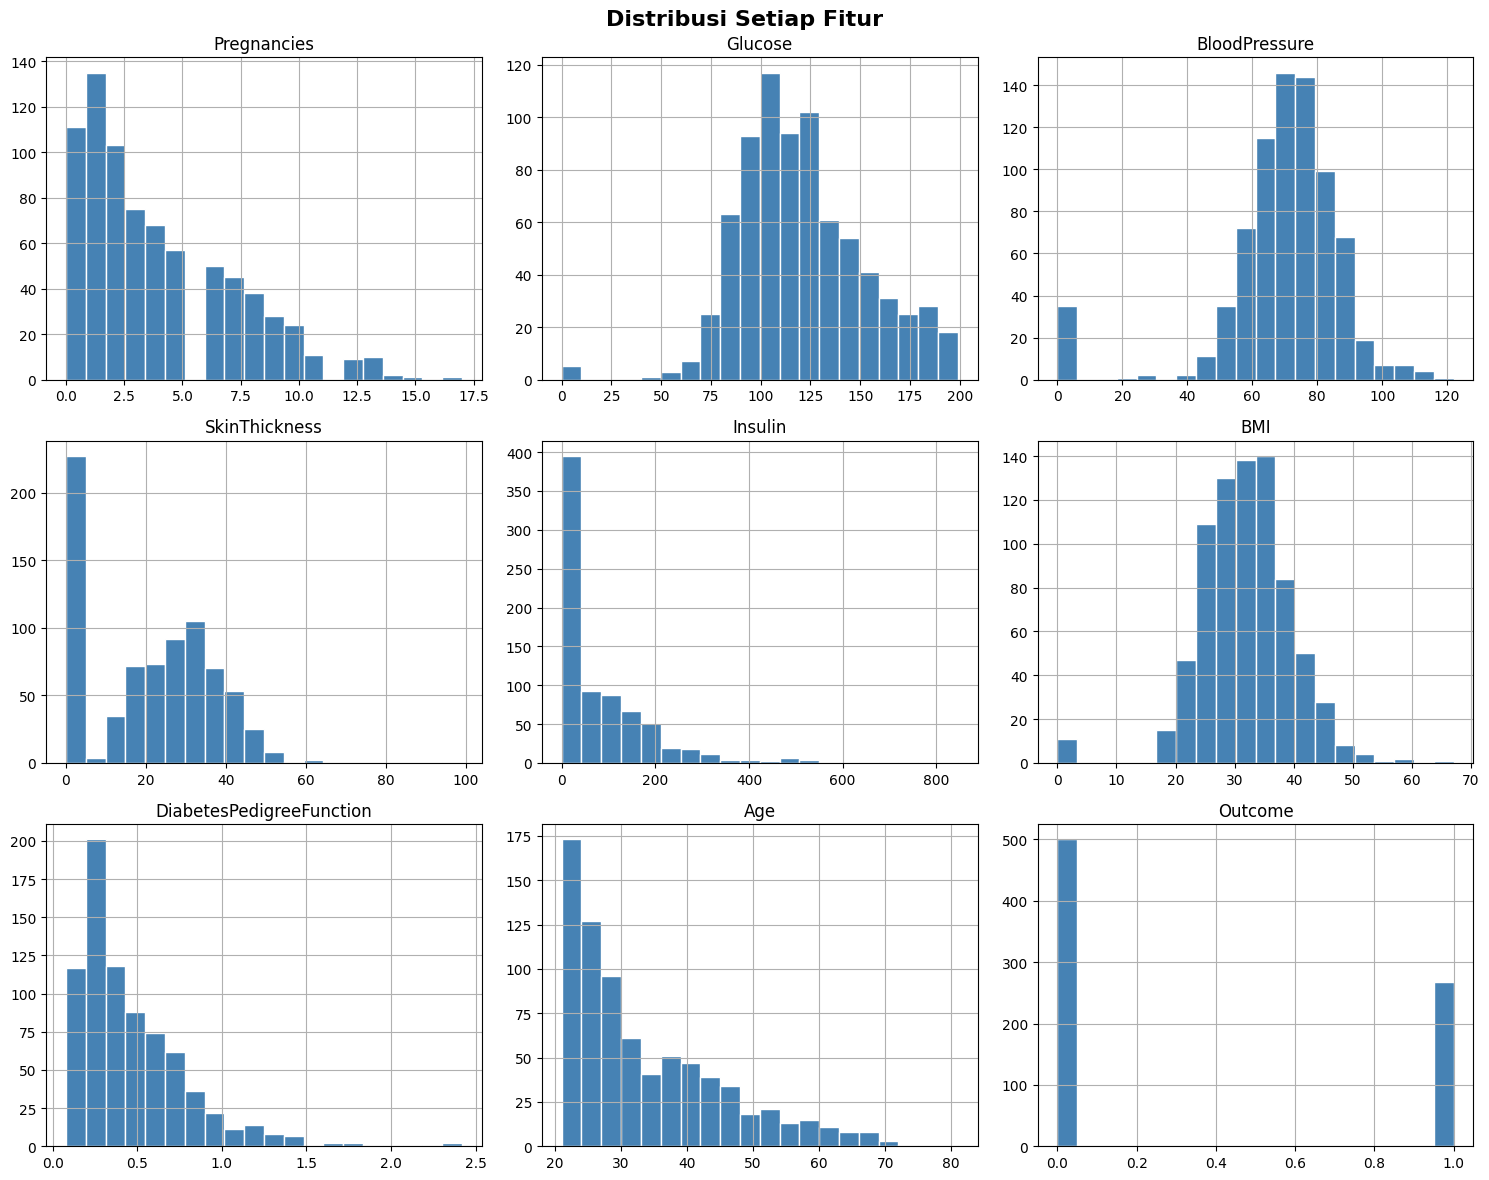

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2.3 Histogram semua fitur
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribusi Setiap Fitur', fontsize=16, fontweight='bold')

for i, col in enumerate(df.columns):
    ax = axes[i // 3][i % 3]
    df[col].hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

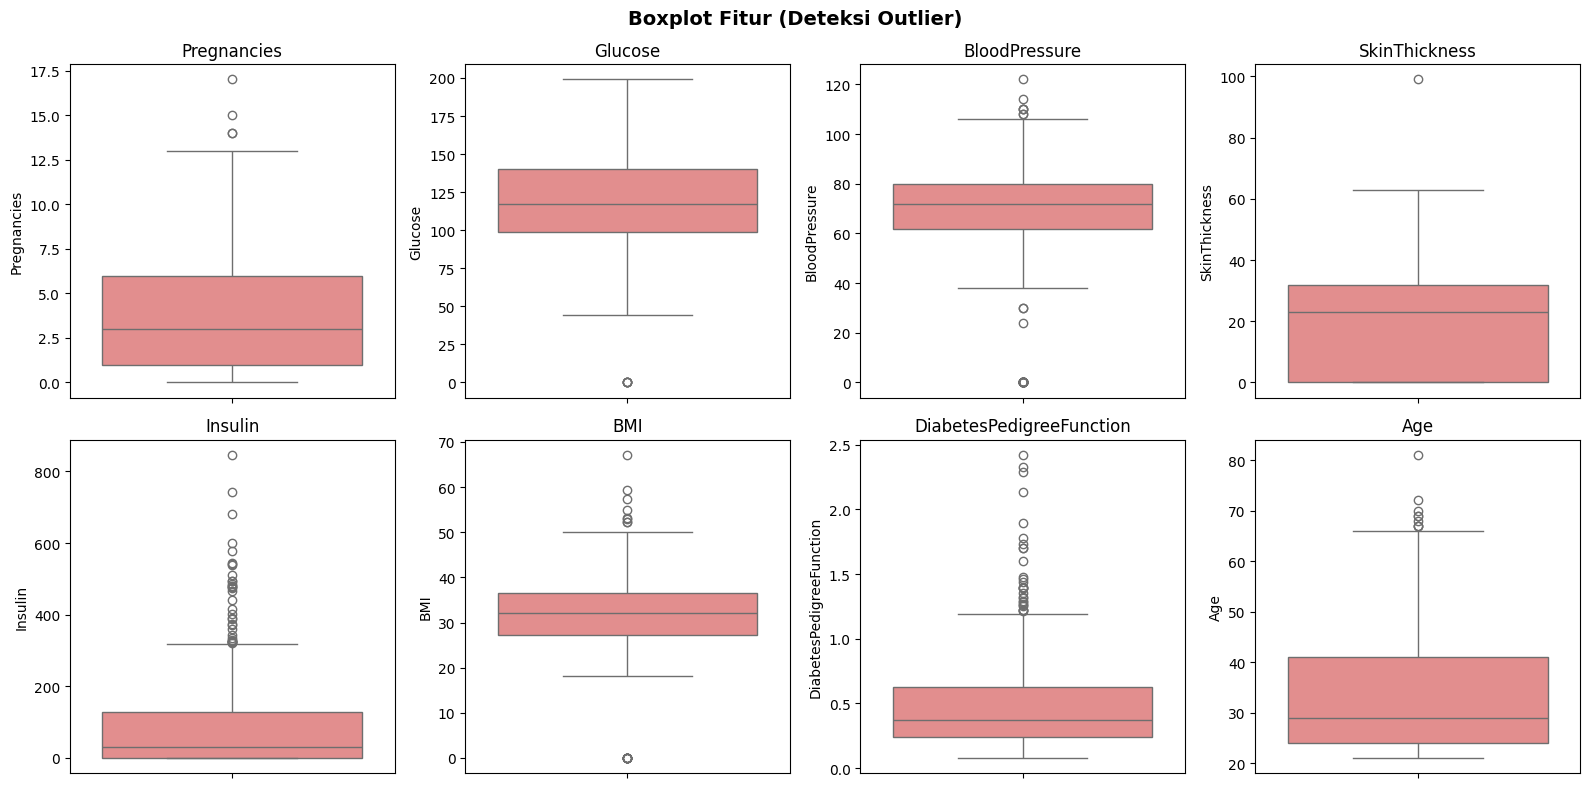

In [6]:
# 2.4 Boxplot untuk identifikasi outlier
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Boxplot Fitur (Deteksi Outlier)', fontsize=14, fontweight='bold')

for i, col in enumerate(features):
    ax = axes[i // 4][i % 4]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)

plt.tight_layout()
plt.show()

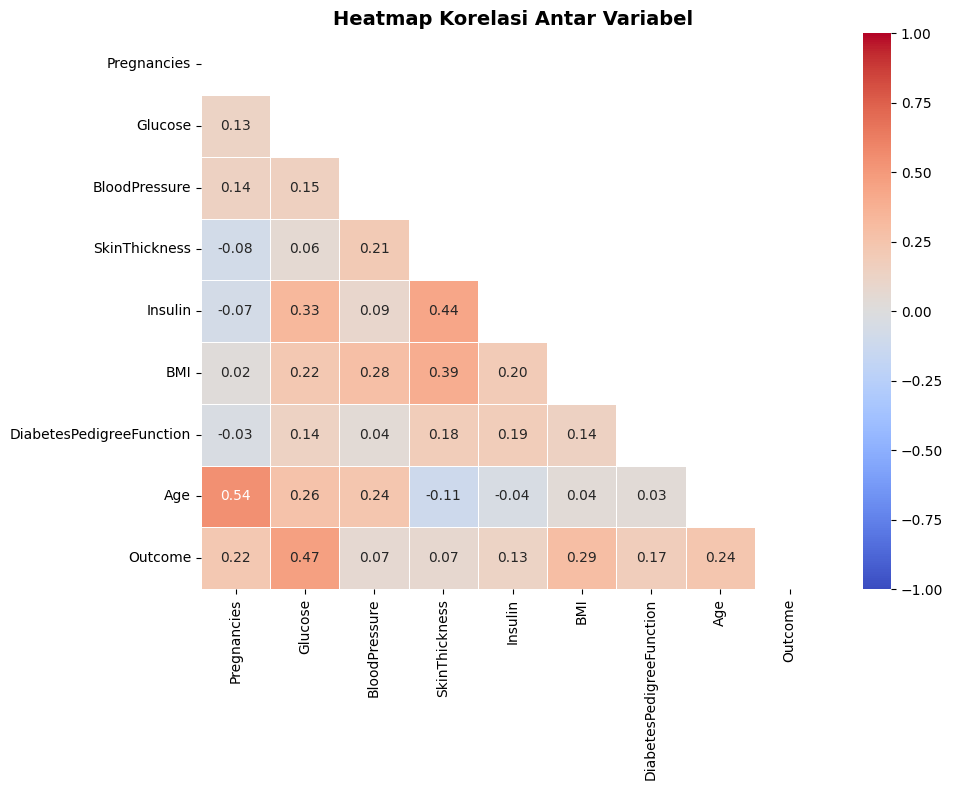


Korelasi fitur terhadap Outcome (diurutkan):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [7]:
# 2.5 Heatmap korelasi
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Fitur dengan korelasi tertinggi terhadap Outcome
print("\nKorelasi fitur terhadap Outcome (diurutkan):")
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False))

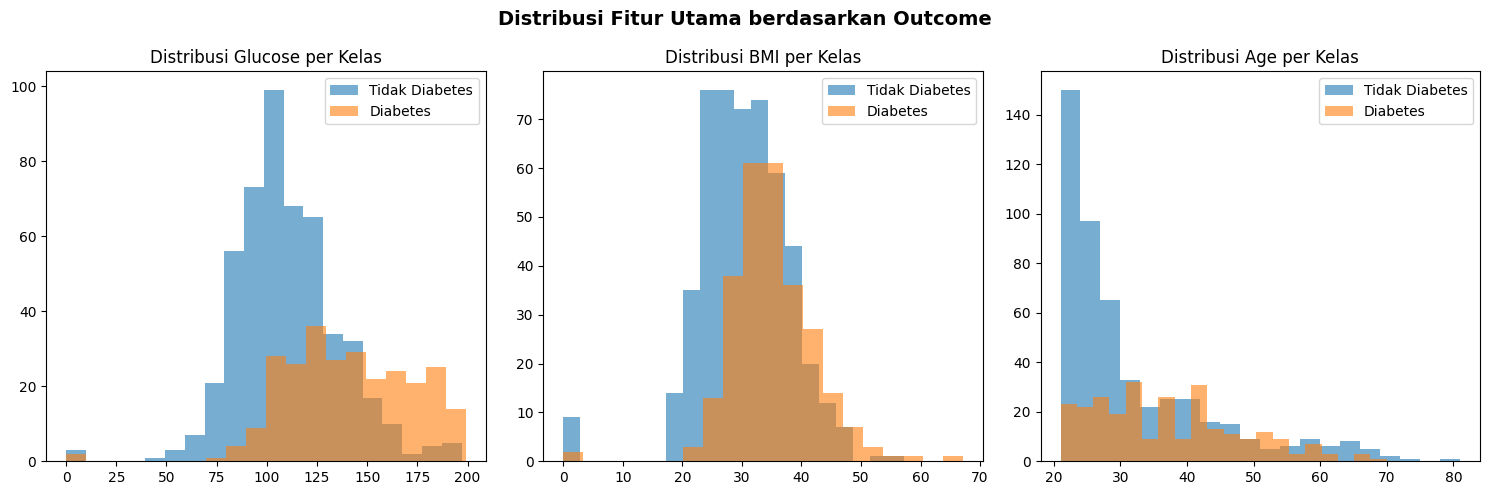

In [8]:
# 2.6 Distribusi target berdasarkan fitur utama
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
top_features = ['Glucose', 'BMI', 'Age']

for i, col in enumerate(top_features):
    for outcome in [0, 1]:
        label = 'Tidak Diabetes' if outcome == 0 else 'Diabetes'
        axes[i].hist(df[df['Outcome'] == outcome][col], bins=20,
                     alpha=0.6, label=label)
    axes[i].set_title(f'Distribusi {col} per Kelas')
    axes[i].legend()

plt.suptitle('Distribusi Fitur Utama berdasarkan Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing
- Tangani missing values dengan metode seperti imputasi (mean/median untuk numerik, mode untuk kategorikal) atau penghapusan baris/kolom jika diperlukan.
- Lakukan encoding untuk variabel kategorikal, misalnya menggunakan one-hot encoding atau label encoding.
- Normalisasi atau standarisasi fitur numerik untuk memastikan skala yang seragam, terutama jika menggunakan model berbasis jarak seperti KNN.
- Pisahkan dataset menjadi fitur (X) dan target (y), serta bagi menjadi data training dan testing (misalnya 80:20).
- Jika diperlukan, lakukan feature selection atau engineering untuk meningkatkan performa model.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 3.1 Tangani nilai 0 yang tidak logis (bukan missing value sesungguhnya)
# Kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, BMI tidak bisa bernilai 0
cols_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Jumlah nilai 0 pada kolom yang tidak valid:")
for col in cols_zero_invalid:
    count = (df[col] == 0).sum()
    print(f"  {col}: {count} nilai nol")

# Ganti nilai 0 dengan median kolom tersebut
df_clean = df.copy()
for col in cols_zero_invalid:
    median_val = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print("\nNilai 0 berhasil diganti dengan median masing-masing kolom.")

Jumlah nilai 0 pada kolom yang tidak valid:
  Glucose: 5 nilai nol
  BloodPressure: 35 nilai nol
  SkinThickness: 227 nilai nol
  Insulin: 374 nilai nol
  BMI: 11 nilai nol

Nilai 0 berhasil diganti dengan median masing-masing kolom.


In [10]:
# 3.2 Semua fitur sudah numerik, tidak perlu encoding
print("Tipe data setelah preprocessing:")
print(df_clean.dtypes)
print("\nSemua fitur bersifat numerik, encoding tidak diperlukan.")

Tipe data setelah preprocessing:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Semua fitur bersifat numerik, encoding tidak diperlukan.


In [11]:
# 3.3 Pisahkan fitur (X) dan target (y)
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print(f"Ukuran X : {X.shape}")
print(f"Ukuran y : {y.shape}")
print(f"\nFitur yang digunakan: {list(X.columns)}")

Ukuran X : (768, 8)
Ukuran y : (768,)

Fitur yang digunakan: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [12]:
# 3.4 Split data train-test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Training : {X_train.shape[0]} baris")
print(f"Data Testing  : {X_test.shape[0]} baris")

Data Training : 614 baris
Data Testing  : 154 baris


In [13]:
# 3.5 Normalisasi / Standarisasi fitur (penting untuk KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Standarisasi selesai.")
print(f"Mean fitur setelah scaling (train): {X_train_scaled.mean(axis=0).round(4)}")

Standarisasi selesai.
Mean fitur setelah scaling (train): [-0. -0.  0. -0. -0. -0. -0. -0.]


## 4. Modelling
- Pilih dan implementasikan tiga model Supervised Learning: Decision Tree, Naive Bayes, dan KNN.
- Untuk Decision Tree: Gunakan algoritma pohon keputusan untuk klasifikasi atau regresi, atur parameter dasar seperti max_depth.
- Untuk Naive Bayes: Terapkan model probabilitas berbasis teorema Bayes, cocok untuk data kategorikal atau numerik dengan asumsi independensi fitur.
- Untuk KNN (K-Nearest Neighbors): Gunakan algoritma berbasis jarak, tentukan nilai K (jumlah tetangga) yang optimal.
- Latih masing-masing model menggunakan data training dan pastikan model dapat memprediksi data testing.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# 4.1 Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)  # Decision Tree tidak perlu scaling

print("Decision Tree berhasil dilatih.")
print(f"  Akurasi Training : {dt_model.score(X_train, y_train):.4f}")
print(f"  Akurasi Testing  : {dt_model.score(X_test, y_test):.4f}")

Decision Tree berhasil dilatih.
  Akurasi Training : 0.8143
  Akurasi Testing  : 0.7597


In [15]:
# 4.2 Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes berhasil dilatih.")
print(f"  Akurasi Training : {nb_model.score(X_train, y_train):.4f}")
print(f"  Akurasi Testing  : {nb_model.score(X_test, y_test):.4f}")

Naive Bayes berhasil dilatih.
  Akurasi Training : 0.7638
  Akurasi Testing  : 0.7013


In [16]:
# 4.3 KNN (K-Nearest Neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)  # KNN membutuhkan data yang sudah di-scaling

print("KNN berhasil dilatih.")
print(f"  Akurasi Training : {knn_model.score(X_train_scaled, y_train):.4f}")
print(f"  Akurasi Testing  : {knn_model.score(X_test_scaled, y_test):.4f}")

KNN berhasil dilatih.
  Akurasi Training : 0.8306
  Akurasi Testing  : 0.7532


## 5. Eksperiment
- Lakukan Cross-Validation untuk mengevaluasi stabilitas model, misalnya menggunakan 5-fold atau 10-fold CV pada data training.
- Terapkan K-Fold Cross-Validation secara eksplisit untuk membagi data menjadi K subset dan hitung rata-rata performa.
- Lakukan Hyperparameter Tuning untuk setiap model, seperti mencari nilai optimal untuk max_depth di Decision Tree, K di KNN, atau parameter smoothing di Naive Bayes, menggunakan teknik seperti Grid Search atau Random Search.
- Bandingkan hasil eksperiment untuk menentukan konfigurasi terbaik bagi masing-masing model.

In [17]:
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5.1 Cross-Validation 5-Fold untuk setiap model
print("=== 5-Fold Cross-Validation ===")

# Decision Tree
cv_dt = cross_val_score(dt_model, X, y, cv=kf, scoring='accuracy')
print(f"\nDecision Tree  : {cv_dt.round(4)}")
print(f"  Rata-rata     : {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")

# Naive Bayes
cv_nb = cross_val_score(nb_model, X, y, cv=kf, scoring='accuracy')
print(f"\nNaive Bayes    : {cv_nb.round(4)}")
print(f"  Rata-rata     : {cv_nb.mean():.4f} ± {cv_nb.std():.4f}")

# KNN (gunakan data scaled)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
cv_knn = cross_val_score(knn_pipeline, X, y, cv=kf, scoring='accuracy')
print(f"\nKNN            : {cv_knn.round(4)}")
print(f"  Rata-rata     : {cv_knn.mean():.4f} ± {cv_knn.std():.4f}")

=== 5-Fold Cross-Validation ===

Decision Tree  : [0.7273 0.7597 0.7403 0.8039 0.7516]
  Rata-rata     : 0.7566 ± 0.0261

Naive Bayes    : [0.7532 0.7532 0.7338 0.7974 0.7255]
  Rata-rata     : 0.7526 ± 0.0249

KNN            : [0.7208 0.7208 0.7468 0.7582 0.7451]
  Rata-rata     : 0.7383 ± 0.0150


In [18]:
# 5.2 Hyperparameter Tuning - Decision Tree
print("=== Hyperparameter Tuning: Decision Tree ===")

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt,
                       cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print(f"Parameter terbaik : {grid_dt.best_params_}")
print(f"Akurasi CV terbaik: {grid_dt.best_score_:.4f}")
best_dt = grid_dt.best_estimator_

=== Hyperparameter Tuning: Decision Tree ===
Parameter terbaik : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Akurasi CV terbaik: 0.7477


In [19]:
# 5.3 Hyperparameter Tuning - Naive Bayes
print("=== Hyperparameter Tuning: Naive Bayes ===")

param_grid_nb = {'var_smoothing': np.logspace(-10, 0, 20)}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train, y_train)

print(f"Parameter terbaik : {grid_nb.best_params_}")
print(f"Akurasi CV terbaik: {grid_nb.best_score_:.4f}")
best_nb = grid_nb.best_estimator_

=== Hyperparameter Tuning: Naive Bayes ===
Parameter terbaik : {'var_smoothing': np.float64(0.002335721469090121)}
Akurasi CV terbaik: 0.7655


In [20]:
# 5.4 Hyperparameter Tuning - KNN
print("=== Hyperparameter Tuning: KNN ===")

param_grid_knn = {
    'knn__n_neighbors': list(range(1, 21)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print(f"Parameter terbaik : {grid_knn.best_params_}")
print(f"Akurasi CV terbaik: {grid_knn.best_score_:.4f}")
best_knn = grid_knn.best_estimator_

=== Hyperparameter Tuning: KNN ===
Parameter terbaik : {'knn__metric': 'euclidean', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
Akurasi CV terbaik: 0.7818


In [21]:
# 5.5 Ringkasan perbandingan hasil CV
cv_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'KNN'],
    'CV Mean Accuracy': [cv_dt.mean(), cv_nb.mean(), cv_knn.mean()],
    'CV Std': [cv_dt.std(), cv_nb.std(), cv_knn.std()],
    'Best CV (Tuned)': [grid_dt.best_score_, grid_nb.best_score_, grid_knn.best_score_]
}).round(4)

print(cv_results.to_string(index=False))

        Model  CV Mean Accuracy  CV Std  Best CV (Tuned)
Decision Tree            0.7566  0.0261           0.7477
  Naive Bayes            0.7526  0.0249           0.7655
          KNN            0.7383  0.0150           0.7818


## 6. Evaluasi
- Evaluasi performa model menggunakan metrik: Confusion Matrix (untuk melihat true positive, false positive, dll.), F1-Score (untuk balance antara precision dan recall), dan Akurasi (persentase prediksi benar).
- Hitung metrik ini untuk setiap model pada data testing, dan bandingkan hasilnya.
- Analisis hasil evaluasi untuk mengidentifikasi kekuatan dan kelemahan masing-masing model, seperti overfitting atau underfitting.

In [22]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)

# Prediksi menggunakan model terbaik hasil tuning
y_pred_dt  = best_dt.predict(X_test)
y_pred_nb  = best_nb.predict(X_test)
y_pred_knn = best_knn.predict(X_test)

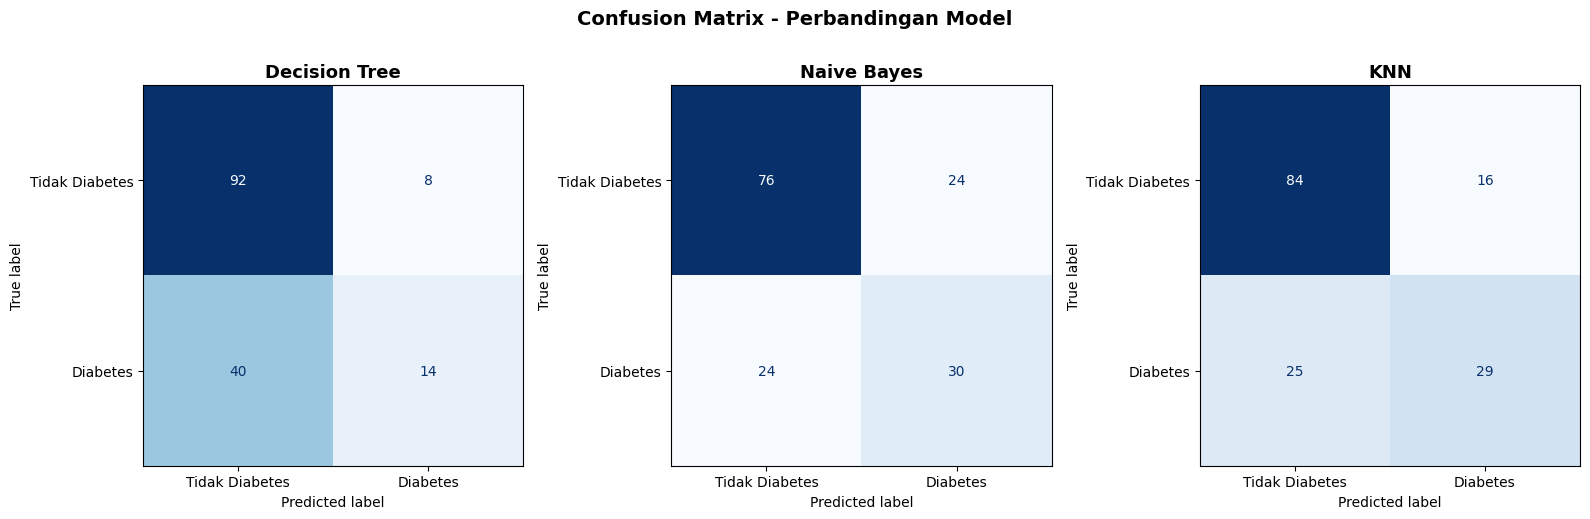

In [23]:
# 6.1 Confusion Matrix untuk semua model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_info = [
    ('Decision Tree', y_pred_dt),
    ('Naive Bayes',   y_pred_nb),
    ('KNN',           y_pred_knn)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix - Perbandingan Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# 6.2 Classification Report tiap model
for name, y_pred in models_info:
    print(f"\n{'='*45}")
    print(f"  {name}")
    print('='*45)
    print(classification_report(y_test, y_pred, target_names=['Tidak Diabetes', 'Diabetes']))


  Decision Tree
                precision    recall  f1-score   support

Tidak Diabetes       0.70      0.92      0.79       100
      Diabetes       0.64      0.26      0.37        54

      accuracy                           0.69       154
     macro avg       0.67      0.59      0.58       154
  weighted avg       0.68      0.69      0.64       154


  Naive Bayes
                precision    recall  f1-score   support

Tidak Diabetes       0.76      0.76      0.76       100
      Diabetes       0.56      0.56      0.56        54

      accuracy                           0.69       154
     macro avg       0.66      0.66      0.66       154
  weighted avg       0.69      0.69      0.69       154


  KNN
                precision    recall  f1-score   support

Tidak Diabetes       0.77      0.84      0.80       100
      Diabetes       0.64      0.54      0.59        54

      accuracy                           0.73       154
     macro avg       0.71      0.69      0.69       154
 

In [25]:
# 6.3 Tabel perbandingan metrik semua model
eval_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_knn, average='macro')
    ],
    'F1-Score (Weighted)': [
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted')
    ]
}).round(4)

print("=== Perbandingan Metrik Evaluasi ===")
print(eval_results.to_string(index=False))

=== Perbandingan Metrik Evaluasi ===
        Model  Accuracy  F1-Score (Macro)  F1-Score (Weighted)
Decision Tree    0.6883            0.5808               0.6442
  Naive Bayes    0.6883            0.6578               0.6883
          KNN    0.7338            0.6948               0.7274


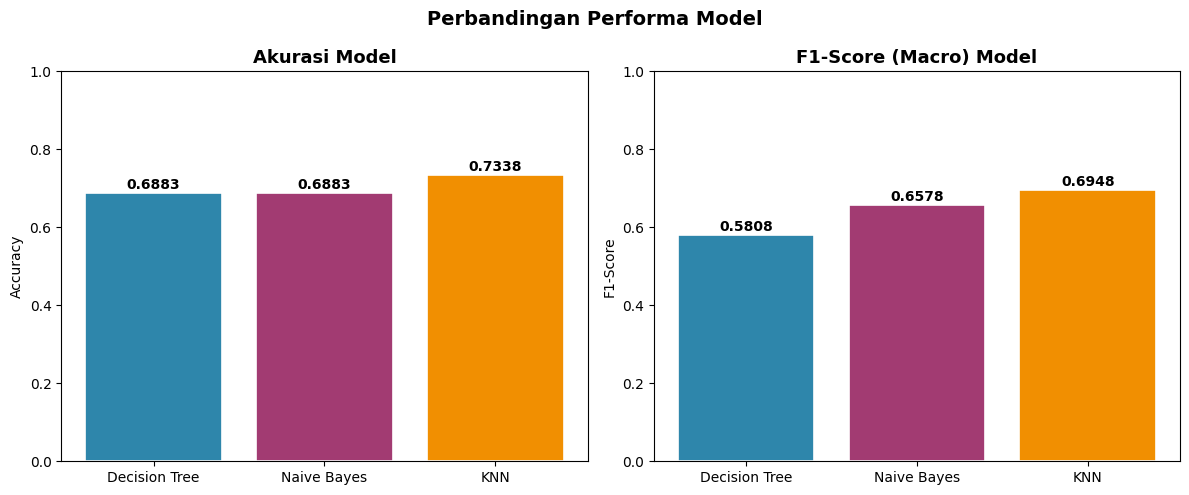


Model dengan akurasi tertinggi: KNN


In [27]:
# 6.4 Visualisasi perbandingan akurasi dan F1-Score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = eval_results['Model']
colors = ['#2E86AB', '#A23B72', '#F18F01']

# Accuracy
axes[0].bar(model_names, eval_results['Accuracy'], color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_ylim(0, 1)
axes[0].set_title('Akurasi Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(eval_results['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# F1-Score
axes[1].bar(model_names, eval_results['F1-Score (Macro)'], color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_ylim(0, 1)
axes[1].set_title('F1-Score (Macro) Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
for i, v in enumerate(eval_results['F1-Score (Macro)']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Perbandingan Performa Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Kesimpulan model terbaik
best_model = eval_results.loc[eval_results['Accuracy'].idxmax(), 'Model']
print(f"\nModel dengan akurasi tertinggi: {best_model}")

## 7. Rangkuman

Hands-on ini membahas alur lengkap supervised learning pakai dataset diabetes dari Kaggle. Awalnya data di-load ke pandas, terus dicek strukturnya yang punya 9 fitur dengan Outcome sebagai target. Waktu EDA, keliatan beberapa fitur kayak Insulin dan SkinThickness itu skewed dan banyak outlier, terus datanya juga agak imbalance (lebih banyak yang non-diabetes). Selain itu ada nilai 0 yang ternyata nggak valid secara medis, jadi harus dibersihin.

Di preprocessing, nilai 0 tadi diganti pakai median biar lebih masuk akal, terus data di-split 80:20 dengan stratifikasi, dan khusus KNN dilakukan scaling pakai StandardScaler. Di tahap modelling, dipakai tiga model: Decision Tree, Naive Bayes, dan KNN, yang masing-masing punya cara kerja dan karakteristik berbeda. Supaya hasilnya lebih fair, dipakai 5-fold cross-validation, dan performanya ditingkatin lagi pakai GridSearch buat cari hyperparameter terbaik.

Terakhir, evaluasi model pakai confusion matrix, F1-score, dan akurasi. Dari sini keliatan kalau nggak ada model yang selalu paling bagus, semuanya tergantung data dan kebutuhan. Intinya, yang paling kerasa itu pentingnya data cleaning, pemilihan metrik yang tepat (nggak cuma akurasi), dan tuning model biar performanya maksimal.